# Aula Prática: Fundamentos de Grafos para Deep Learning

**Objetivo:** Esta aula prática visa solidificar os conceitos fundamentais de teoria dos grafos usando a biblioteca `NetworkX`.

---

In [9]:
%pip install networkx numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Instalação e Importação das Bibliotecas
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms import community

print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.6.1


## Exercício 1: Representação Computacional e Matrizes

Em Deep Learning, não passamos o "desenho" do grafo para a rede, mas sim suas representações matriciais. A mais comum é a **Matriz de Adjacência ($A$)**.

**Tarefa:**
1. Crie um grafo não direcionado com 5 a 6 nós representando conexões simples.
2. Visualize o grafo.
3. Extraia e imprima a **Matriz de Adjacência** (numpy array).
4. Extraia a **Lista de Arestas** (Edge List).

*Dica: Observe a simetria da matriz de adjacência. O que ela indica?*

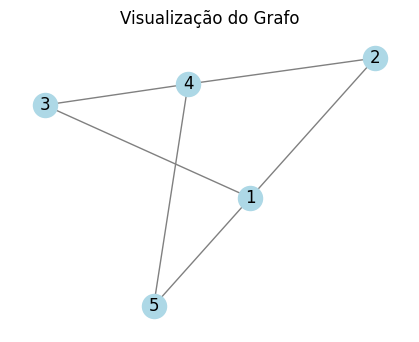


Matriz de Adjacência (A):
 [[0. 1. 1. 0. 1.]
 [1. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1.]
 [1. 0. 0. 1. 0.]]

Edge List: [(1, 2), (1, 3), (1, 5), (2, 4), (3, 4), (4, 5)]


In [11]:
# 1. Criar o grafo
G = nx.Graph()
edges = [(1, 2), (1, 3), (2, 4), (3, 4), (4, 5), (1, 5)]
G.add_edges_from(edges)

# 2. Visualizar
plt.figure(figsize=(4,3))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Visualização do Grafo")
plt.show()

# 3. Matriz de Adjacência
# Em GNNs, essa matriz 'A' é multiplicada pela matriz de Features 'X' (A*X)
A = nx.to_numpy_array(G)
print("\nMatriz de Adjacência (A):\n", A)

# 4. Lista de Arestas
print("\nEdge List:", G.edges())

## Exercício 2: Análise de Topologia (Feature Engineering)

Antes do Deep Learning em grafos, usávamos métricas de topologia como *features* para modelos de ML clássico. Vamos analisar o famoso dataset **Zachary's Karate Club**.

**Tarefa:**
1. Carregue o grafo do Karate Club (`nx.karate_club_graph()`).
2. Identifique os **Hubs**: Encontre os 3 nós com maior **Grau** (Degree).
3. Identifique os **Pontes**: Encontre os 3 nós com maior **Betweenness Centrality** (Intermediação).
4. Plote o grafo onde o tamanho do nó é proporcional ao seu Grau.

Top 3 Nós por Grau: [(33, 17), (0, 16), (32, 12)]
Top 3 Nós por Intermediação: [(0, 0.43763528138528146), (33, 0.30407497594997596), (32, 0.145247113997114)]


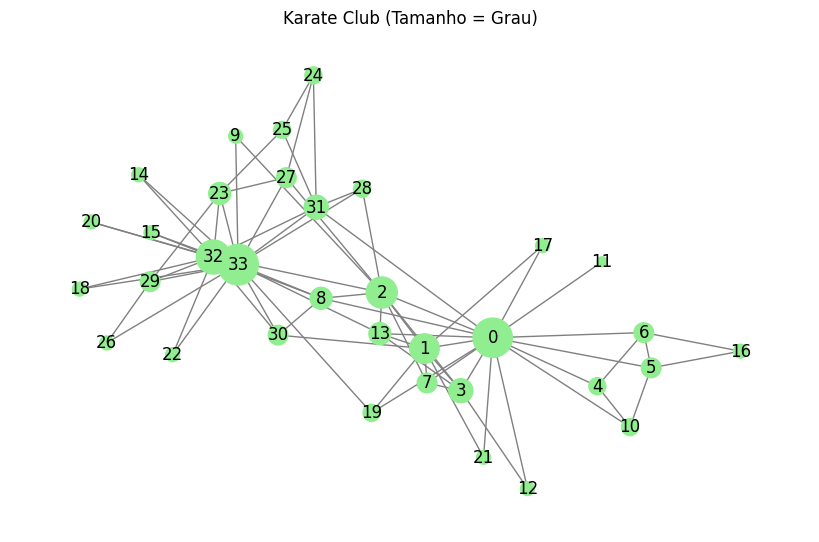

In [12]:
G_karate = nx.karate_club_graph()

# 2. Grau (Degree)
degrees = dict(G_karate.degree())
# Ordenando para achar os top 3
top_degrees = sorted(degrees.items(), key=lambda item: item[1], reverse=True)[:3]
print("Top 3 Nós por Grau:", top_degrees)

# 3. Betweenness Centrality
bet_cen = nx.betweenness_centrality(G_karate)
top_betweenness = sorted(bet_cen.items(), key=lambda item: item[1], reverse=True)[:3]
print("Top 3 Nós por Intermediação:", top_betweenness)

# 4. Visualização Proporcional
node_sizes = [v * 50 for v in degrees.values()] # Escala para visualização

plt.figure(figsize=(8,5))
nx.draw(G_karate, with_labels=True, node_size=node_sizes, node_color='lightgreen', edge_color='gray')
plt.title("Karate Club (Tamanho = Grau)")
plt.show()

## Exercício 3: O Algoritmo PageRank

O PageRank define importância de forma recursiva. Isso é análogo a mecanismos de atenção em redes neurais, onde aprendemos quais vizinhos são mais relevantes.

**Tarefa:**
1. Crie um grafo direcionado (`nx.DiGraph`).
2. Adicione arestas formando um fluxo, mas crie um nó que recebe conexões e não aponta para ninguém (uma "armadilha" ou *sink*).
3. Calcule o PageRank.
4. Plote o grafo do page rank.

PageRank (Grafo Direcionado): {1: 0.3078526047028215, 2: 0.2137621842472386, 3: 0.26462302680270133, 4: 0.2137621842472386}

Top 3 PageRank Karate Club: [(33, 0.09698041880501741), (0, 0.08850807396280012), (32, 0.07592643687005646)]


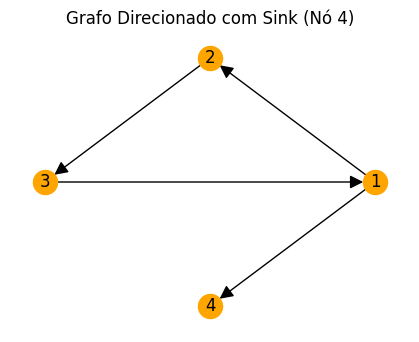

In [13]:
# Criando um grafo direcionado simples
D = nx.DiGraph()
D.add_edges_from([(1, 2), (2, 3), (3, 1), (1, 4)]) # 4 é um 'sink' (recebe de 1 mas não sai)

pagerank_D = nx.pagerank(D, alpha=0.85) # alpha é o damping factor
print("PageRank (Grafo Direcionado):", pagerank_D)

# PageRank no Karate Club
pagerank_K = nx.pagerank(G_karate)
top_pr_k = sorted(pagerank_K.items(), key=lambda x: x[1], reverse=True)[:3]
print("\nTop 3 PageRank Karate Club:", top_pr_k)

plt.figure(figsize=(4,3))
nx.draw_circular(D, with_labels=True, node_color='orange', arrowsize=20)
plt.title("Grafo Direcionado com Sink (Nó 4)")
plt.show()

## Exercício 4: Navegação e Vizinhança (BFS/Shortest Path)

O objetivo desse exercício é encontrar a relação entre os "participantes" (nós) do grafo.

**Tarefa:**
1. Escolha o nó `0` e o nó `33` do Karate Club (que são os líderes das facções opostas).
2. Encontre o caminho mais curto entre eles.
3. Para o nó `0`, liste seus vizinhos diretos.

In [14]:
source = 0
target = 33

# Caminho mais curto
path = nx.shortest_path(G_karate, source=source, target=target)
print(f"Caminho mais curto entre {source} e {target}: {path}")
print(f"Distância (hops): {len(path) - 1}")

# Vizinhança (Aggregation scope)
neighbors = list(G_karate.neighbors(source))
print(f"\nVizinhos imediatos do nó {source} (1-hop): {neighbors}")

# Bônus: Vizinhos de segunda ordem (vizinhos dos vizinhos)
second_order = set()
for n in neighbors:
    for nn in G_karate.neighbors(n):
        if nn != source and nn not in neighbors:
            second_order.add(nn)
print(f"Vizinhos de segunda ordem do nó {source} (2-hops): {list(second_order)}")

Caminho mais curto entre 0 e 33: [0, 8, 33]
Distância (hops): 2

Vizinhos imediatos do nó 0 (1-hop): [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Vizinhos de segunda ordem do nó 0 (2-hops): [32, 33, 9, 16, 24, 25, 27, 28, 30]


## Exercício 5: Detecção de Comunidades

Muitas tarefas de Deep Learning em grafos são de classificação de nós (predizer a qual grupo um nó pertence). Algoritmos clássicos de comunidade servem como *baseline* ou *labels* para treinamento.

**Tarefa:**
1. Use o algoritmo `greedy_modularity_communities` para encontrar grupos no Karate Club.
2. Visualize o grafo colorindo os nós de acordo com o grupo encontrado.


Número de comunidades encontradas: 3


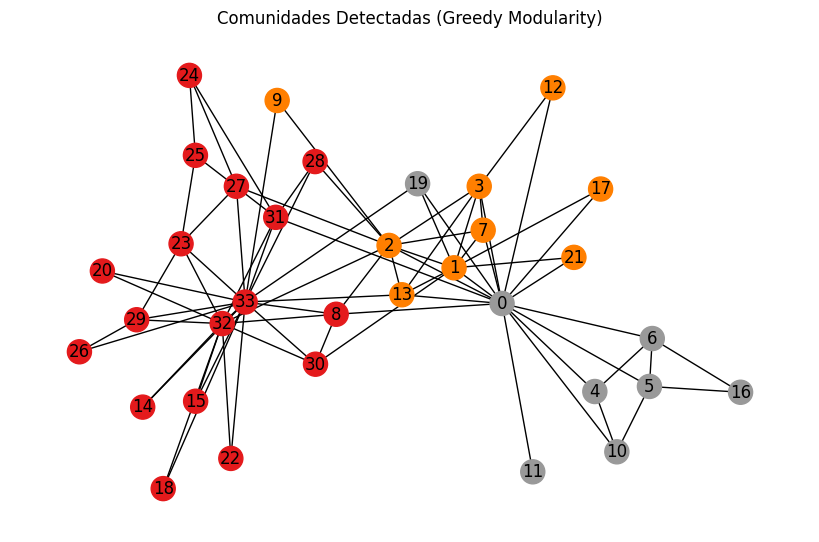

In [15]:
# Detectando comunidades
communities = community.greedy_modularity_communities(G_karate)

# Criando um mapa de cores
color_map = []
# O algoritmo retorna lista de sets (conjuntos) de nós
# Vamos atribuir uma cor (id) para cada set
for node in G_karate:
    for i, comm in enumerate(communities):
        if node in comm:
            color_map.append(i)
            break

print(f"Número de comunidades encontradas: {len(communities)}")

plt.figure(figsize=(8,5))
nx.draw(G_karate, node_color=color_map, with_labels=True, cmap=plt.cm.Set1)
plt.title("Comunidades Detectadas (Greedy Modularity)")
plt.show()